Basics about where I got this data from:
tried to get from here, but too much data for the pull, so I am using the requests.get below instead https://www.ncei.noaa.gov/access/search/data-search/global-hourly?startDate=2015-05-01T00:00:00&endDate=2025-09-30T23:59:59&dataTypes=TMP&dataTypes=DEW&dataTypes=RH1&dataTypes=AA1&dataTypes=GA1&dataTypes=CIG&dataTypes=VIS&dataTypes=AU1&dataTypes=AW1&dataTypes=MW1&dataTypes=WND&bbox=41.984,-87.680,41.955,-87.631&place=Zip%20Code:25305&pageNum=1


In [1]:
import io
import time
import requests
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
#('72534014819', 'Midway'), ('72530094846', "O'Hare")

OHARE = '72530094846'  # Chicago O'Hare
MIDWAY = '72534014819'
YEARS   = range(2021, 2026)
URL     = 'https://www.ncei.noaa.gov/data/global-hourly/access/{year}/{station}.csv'

ohare_frames = []
for year in YEARS:
    print(f'Fetching {year}...')
    r = requests.get(URL.format(year=year, station=OHARE), timeout=60)
    if r.status_code == 200:
        ohare_frames.append(pd.read_csv(io.BytesIO(r.content), low_memory=False))
    time.sleep(0.3)

midway_frames = []
for year in YEARS:
    print(f'Fetching {year}...')
    r = requests.get(URL.format(year=year, station=MIDWAY), timeout=60)
    if r.status_code == 200:
        midway_frames.append(pd.read_csv(io.BytesIO(r.content), low_memory=False))
    time.sleep(0.3)



Fetching 2021...
Fetching 2022...
Fetching 2023...
Fetching 2024...
Fetching 2025...
Fetching 2021...
Fetching 2022...
Fetching 2023...
Fetching 2024...
Fetching 2025...


In [3]:
lists = [midway_frames, ohare_frames]
print("~~~Midway~~~")
for df in midway_frames:
    print(len(df))
    print(df.columns)
print("~~~Ohare~~~")
for df in ohare_frames:
    print(len(df))
    print(df.columns)

~~~Midway~~~
12120
Index(['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG',
       'VIS', 'TMP', 'DEW', 'SLP', 'AA1', 'AA2', 'AA3', 'AB1', 'AD1', 'AE1',
       'AH1', 'AH2', 'AH3', 'AH4', 'AH5', 'AH6', 'AI1', 'AI2', 'AI3', 'AI4',
       'AI5', 'AI6', 'AJ1', 'AL1', 'AT1', 'AT2', 'AT3', 'AT4', 'AT5', 'AT6',
       'AT7', 'AT8', 'AU1', 'AU2', 'AU3', 'AW1', 'AW2', 'AW3', 'AW4', 'AW5',
       'AX1', 'AX2', 'AX3', 'AX4', 'ED1', 'GA1', 'GA2', 'GA3', 'GD1', 'GD2',
       'GD3', 'GD4', 'GE1', 'GF1', 'KA1', 'KA2', 'KA3', 'KA4', 'KB1', 'KB2',
       'KB3', 'KC1', 'KC2', 'KD1', 'KD2', 'KE1', 'MA1', 'MD1', 'MG1', 'MH1',
       'MK1', 'MV1', 'MW1', 'MW2', 'MW3', 'OC1', 'OD1', 'OE1', 'OE2', 'OE3',
       'WA1', 'REM', 'EQD'],
      dtype='object')
12351
Index(['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION',
       'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG',
       '

formating found here https://www.ncei.noaa.gov/data/global-hourly/doc/isd-format-document.pdf
token is just the comman separated pieces in the measurement

| Column | What you get | How to decode | Coverage |
|---|---|---|---|
| `DATE` | UTC timestamp | `pd.to_datetime` | 100% |
| `TMP` | Air temperature | token 0 ÷ 10 → °C (`+0022` = 2.2 °C) | 100% |
| `DEW` | Dew point | same as TMP | 100% |
| `SLP` | Sea-level pressure | token 0 ÷ 10 → hPa (`10131` = 1013.1 hPa) | 100% |
| `WND` | Wind direction + speed | token 0 = degrees, token 3 ÷ 10 = m/s (`320,5,N,0067,5` = 320°, 6.7 m/s) | 100% |
| `VIS` | Visibility | token 0 = meters (`016093` = 16,093 m) | 100% |
| `CIG` | Ceiling height | token 0 = meters AGL (`00457` = 457 m) | 100% |
| `MA1` | Altimeter + station pressure | token 0 ÷ 10 = altimeter hPa, token 2 ÷ 10 = station hPa | 97% |
| `GA1` | Lowest cloud layer | token 0 = oktas (0–8), token 2 = height meters | 90% |
| `AA1` | Precipitation | token 0 = accumulation hours, token 1 ÷ 10 = mm (`01,0000` = 1hr, 0.0 mm) | 82% |
| `GA2` | Second cloud layer | same format as GA1 — only present when there are multiple layers | 49% |
| `OC1` | Wind gust speed | token 0 ÷ 10 = m/s (`0103` = 10.3 m/s) — only logged when a gust occurs | 20% |
| `REM` | Raw METAR string | human-readable, good for spot-checking anything suspicious | 100% |


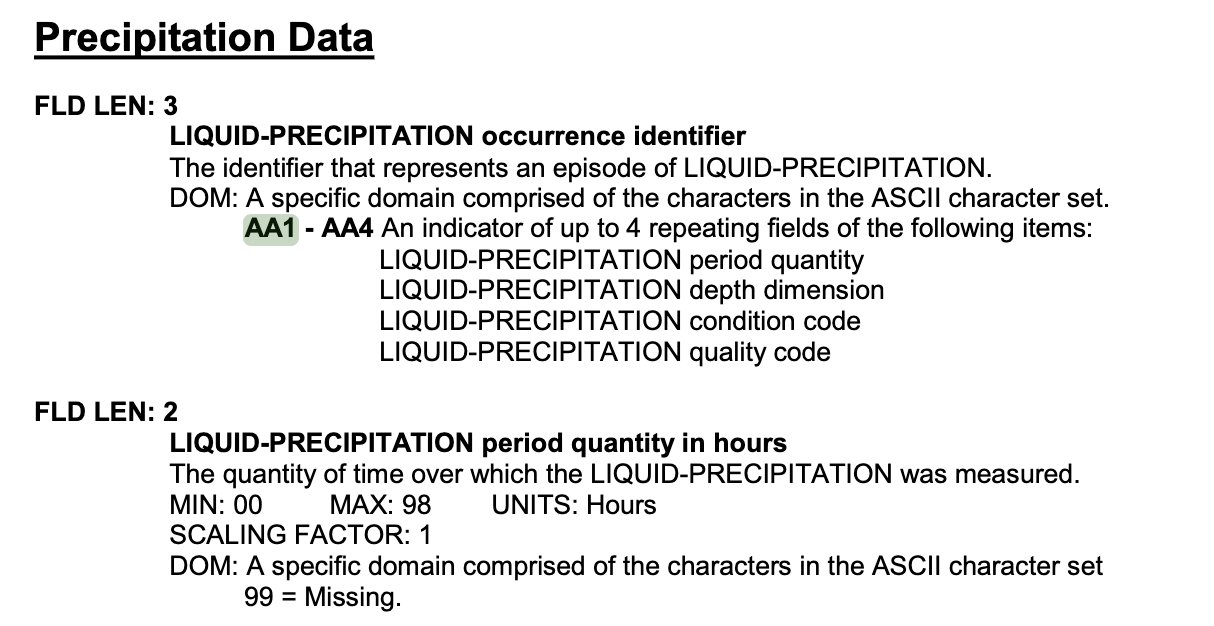
some arent specified but can be assumed?
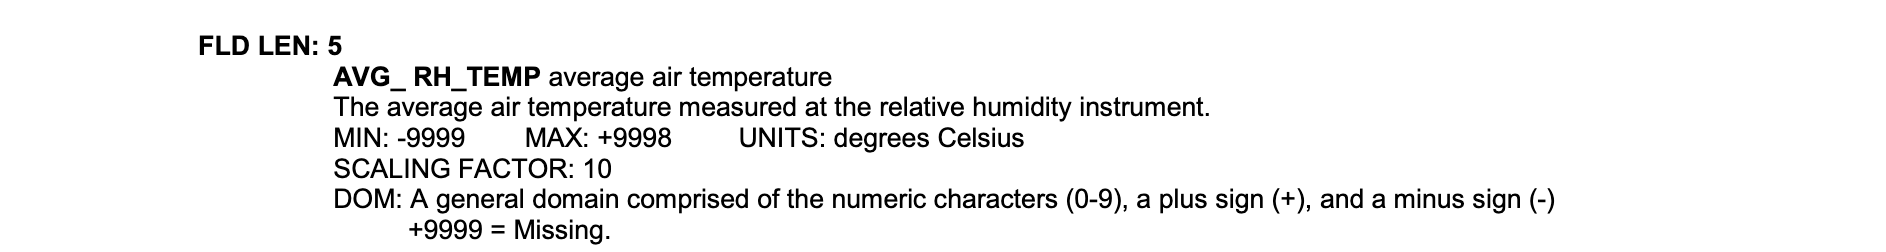

In [4]:
#checking frames
#format found 
# for col in df.columns:
#     print(col)
#     print(type(col))
cropped_midway = []
keep = ['DATE', 'TMP', 'DEW', 'SLP', 'WND', 'AA1', 'OC1', 'MA1', 'REM']
for df in midway_frames:
    df1 = df.copy()
    df1 = df1[keep]
    print(len(df1))
    df1['airport'] = 'midway'
    print(df1.columns)
    
    cropped_midway.append(df1)
print(cropped_midway)

cropped_ohare = []

for df in ohare_frames:
    df1 = df.copy()
    df1 = df1[keep]
    print(len(df1))
    
    df1['airport'] = 'ohare'
    print(df1.columns)
    cropped_ohare.append(df1)
print(cropped_ohare)
    

12120
Index(['DATE', 'TMP', 'DEW', 'SLP', 'WND', 'AA1', 'OC1', 'MA1', 'REM',
       'airport'],
      dtype='object')
12351
Index(['DATE', 'TMP', 'DEW', 'SLP', 'WND', 'AA1', 'OC1', 'MA1', 'REM',
       'airport'],
      dtype='object')
12472
Index(['DATE', 'TMP', 'DEW', 'SLP', 'WND', 'AA1', 'OC1', 'MA1', 'REM',
       'airport'],
      dtype='object')
12079
Index(['DATE', 'TMP', 'DEW', 'SLP', 'WND', 'AA1', 'OC1', 'MA1', 'REM',
       'airport'],
      dtype='object')
7840
Index(['DATE', 'TMP', 'DEW', 'SLP', 'WND', 'AA1', 'OC1', 'MA1', 'REM',
       'airport'],
      dtype='object')
[                      DATE      TMP      DEW      SLP             WND  \
0      2021-01-01T00:53:00  -0033,5  -0078,5  10291,5  999,9,C,0000,5   
1      2021-01-01T01:53:00  -0033,5  -0078,5  10291,5  130,5,N,0015,5   
2      2021-01-01T02:53:00  -0033,5  -0078,5  10288,5  080,5,N,0015,5   
3      2021-01-01T03:00:00  -0033,1  -0078,1  10288,1  080,1,N,0015,1   
4      2021-01-01T03:53:00  -0033,5  -0072,5 

In [5]:
df_concat_oh = pd.concat(cropped_ohare, ignore_index=True)
df_concat_md = pd.concat(cropped_midway, ignore_index=True)
print(df_concat_oh.describe())
df_concat = pd.concat([df_concat_md, df_concat_oh], ignore_index=True)

print(df_concat.dtypes)
print(df_concat.describe())
print(df_concat.shape)
df_concat.head()
df_concat.tail()

                       DATE      TMP      DEW      SLP             WND  \
count                 62036    62036    62036    62036           62036   
unique                61944      316      288     1045            1606   
top     2023-03-23T12:00:00  +9999,9  +9999,9  99999,9  999,9,C,0000,5   
freq                      2     1743     1741    12214            2625   

                AA1     OC1              MA1  \
count         49099   11894            60295   
unique          448      68              465   
top     01,0000,9,5  0108,5  10179,5,09935,5   
freq          33992    1109             1044   

                                                      REM airport  
count                                               62017   62036  
unique                                              62017       1  
top     SYN08672530 32964 62803 11039 21072 30030 4028...   ohare  
freq                                                    1   62036  
DATE       object
TMP        object
DEW        o

,DATE,TMP,DEW,SLP,WND,AA1,OC1,MA1,REM,airport
118893,2025-08-25T07:51:00,"+0139,5","+0089,5","10161,5","310,5,N,0046,5",NaN,NaN,"10163,5,09918,5",MET09508/25/25 01:51:01 METAR KORD 250751Z 310...,ohare
118894,2025-08-25T08:51:00,"+0133,5","+0089,5","10163,5","310,5,N,0036,5",NaN,NaN,"10166,5,09921,5",MET10108/25/25 02:51:01 METAR KORD 250851Z 310...,ohare
118895,2025-08-25T09:51:00,"+0128,5","+0094,5","10163,5","320,5,N,0036,5",NaN,NaN,"10166,5,09921,5",MET10208/25/25 03:51:01 METAR KORD 250951Z 320...,ohare
118896,2025-08-25T10:51:00,"+0128,5","+0094,5","10166,5","320,5,N,0041,5",NaN,NaN,"10169,5,09925,5",MET10908/25/25 04:51:01 METAR KORD 251051Z 320...,ohare
118897,2025-08-25T11:51:00,"+0128,5","+0094,5","10173,5","300,5,N,0041,5",NaN,NaN,"10176,5,09931,5",MET12708/25/25 05:51:01 METAR KORD 251151Z 300...,ohare


In [6]:
# print(df_concat_oh.head())
# # print(df_concat_oh.tail())
# print(df_concat_md.head())
# print(df_concat_md.tail())
print(len(df_concat_md))
print(len(df_concat_oh))
print(len(df_concat))

56862
62036
118898


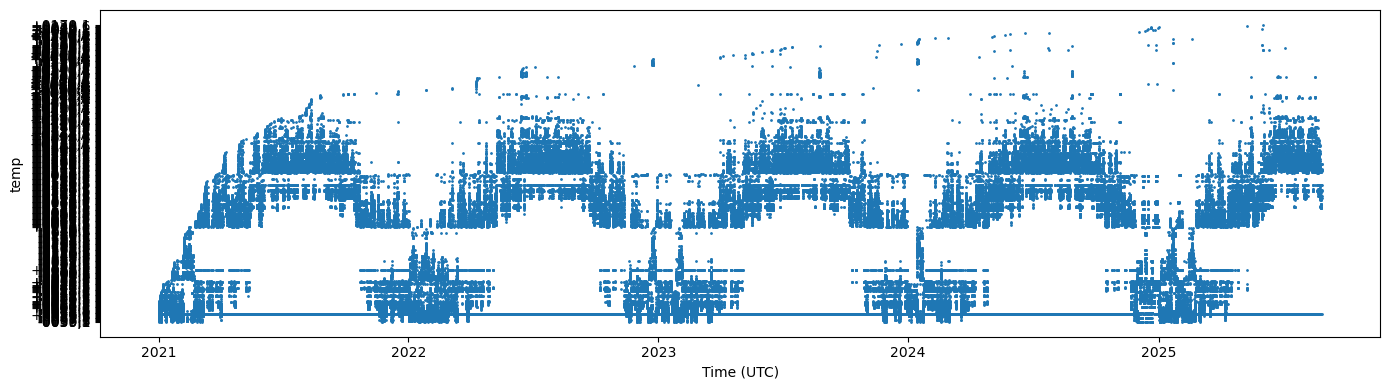

                  DATE      TMP      DEW      SLP             WND  \
0  2021-01-01T00:00:00  -0039,1  -0072,1  10280,1  280,1,N,0015,1   
1  2021-01-01T00:51:00  -0050,5  -0078,5  10282,5  330,5,N,0015,5   
2  2021-01-01T00:53:00  -0033,5  -0078,5  10291,5  999,9,C,0000,5   
3  2021-01-01T01:51:00  -0050,5  -0083,5  10281,5  020,5,N,0031,5   
4  2021-01-01T01:53:00  -0033,5  -0078,5  10291,5  130,5,N,0015,5   

           AA1  OC1              MA1  \
0          NaN  NaN  99999,9,10030,1   
1  01,0000,9,5  NaN  10271,5,10024,5   
2  01,0000,9,5  NaN  10274,5,10048,5   
3  01,0000,9,5  NaN  10271,5,10024,5   
4  01,0000,9,5  NaN  10274,5,10048,5   

                                                 REM airport  \
0  SYN08672530 32964 62803 11039 21072 30030 4028...   ohare   
1  MET10612/31/20 18:51:03 METAR KORD 010051Z 330...   ohare   
2  MET10612/31/20 18:53:03 METAR KMDW 010053Z 000...  midway   
3  MET10612/31/20 19:51:03 METAR KORD 010151Z 020...   ohare   
4  MET09912/31/20 19:53:

In [11]:
#making date to utc datetime
df_concat['datetime_utc'] = pd.to_datetime(df_concat['DATE'], utc=True, errors='coerce')

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(df_concat['datetime_utc'], df_concat['TMP'], s=1)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("temp")
plt.tight_layout()
plt.show()

df_concat = df_concat.sort_values('datetime_utc').reset_index(drop=True)
print(df_concat.head())
print(df_concat.tail())


In [13]:
# fig, ax = plt.subplots(figsize=(14, 4))
# ax.scatter(df_concat['datetime_utc'], df_concat['AA1'], s=1)
# ax.set_xlabel("Time (UTC)")
# ax.set_ylabel("precip")
# plt.tight_layout()
# plt.show()

# df_concat = df_concat.sort_values('datetime_utc').reset_index(drop=True)
# print(df_concat.head())
# print(df_concat.tail())

In [8]:
print(df_concat.head())
print(df_concat.tail())

                  DATE      TMP      DEW      SLP             WND  \
0  2021-01-01T00:00:00  -0039,1  -0072,1  10280,1  280,1,N,0015,1   
1  2021-01-01T00:51:00  -0050,5  -0078,5  10282,5  330,5,N,0015,5   
2  2021-01-01T00:53:00  -0033,5  -0078,5  10291,5  999,9,C,0000,5   
3  2021-01-01T01:51:00  -0050,5  -0083,5  10281,5  020,5,N,0031,5   
4  2021-01-01T01:53:00  -0033,5  -0078,5  10291,5  130,5,N,0015,5   

           AA1  OC1              MA1  \
0          NaN  NaN  99999,9,10030,1   
1  01,0000,9,5  NaN  10271,5,10024,5   
2  01,0000,9,5  NaN  10274,5,10048,5   
3  01,0000,9,5  NaN  10271,5,10024,5   
4  01,0000,9,5  NaN  10274,5,10048,5   

                                                 REM airport  \
0  SYN08672530 32964 62803 11039 21072 30030 4028...   ohare   
1  MET10612/31/20 18:51:03 METAR KORD 010051Z 330...   ohare   
2  MET10612/31/20 18:53:03 METAR KMDW 010053Z 000...  midway   
3  MET10612/31/20 19:51:03 METAR KORD 010151Z 020...   ohare   
4  MET09912/31/20 19:53:

In [9]:
# df_converted = df_concat.copy()
# df_converted = df_converted[['airport', 'datetime_utc', 'temp_c', 'dew_c', 'slp_hpa', 'wind_dir','wind_ms', 'precip_mm', 'precip_hrs', 'gust_ms']]
# df_converted

KeyError: "['temp_c', 'dew_c', 'slp_hpa', 'wind_dir', 'wind_ms', 'precip_mm', 'precip_hrs', 'gust_ms'] not in index"

In [ ]:
df_converted.describe()


,temp_c,dew_c,slp_hpa,wind_dir,wind_ms,precip_mm,precip_hrs,gust_ms
count,118898.000000,118898.000000,118898.000000,108403.000000,118898.000000,95267.000000,95267.000000,23186.000000
mean,40.647425,34.166338,2658.336937,193.204524,33.699982,0.364918,1.988747,11.922630
std,167.055736,168.132147,3472.228822,100.453622,168.135730,6.779592,4.403482,2.698104
min,-23.300000,-30.600000,981.000000,10.000000,0.000000,0.000000,1.000000,7.200000
25%,2.800000,-2.200000,1012.500000,100.000000,3.100000,0.000000,1.000000,10.300000
50%,12.200000,5.600000,1017.900000,210.000000,4.100000,0.000000,1.000000,11.300000
75%,22.000000,15.000000,1027.000000,270.000000,6.200000,0.000000,1.000000,13.400000
max,999.900000,999.900000,9999.900000,360.000000,999.900000,999.900000,24.000000,37.600000


In [ ]:
# Null counts per column
null_counts = df_converted.isnull().sum()

report = pd.DataFrame({
    'null_count':    null_counts,
    'pct_null':      (null_counts / len(df_converted) * 100).round(2),
})
display(report)


,null_count,pct_null
airport,0,0.00
datetime_utc,0,0.00
temp_c,0,0.00
dew_c,0,0.00
slp_hpa,0,0.00
wind_dir,10495,8.83
wind_ms,0,0.00
precip_mm,23631,19.88
precip_hrs,23631,19.88
gust_ms,95712,80.50


              temp_c          dew_c        slp_hpa       wind_dir  \
count  118898.000000  118898.000000  118898.000000  108403.000000   
mean       40.647425      34.166338    2658.336937     193.204524   
std       167.055736     168.132147    3472.228822     100.453622   
min       -23.300000     -30.600000     981.000000      10.000000   
25%         2.800000      -2.200000    1012.500000     100.000000   
50%        12.200000       5.600000    1017.900000     210.000000   
75%        22.000000      15.000000    1027.000000     270.000000   
max       999.900000     999.900000    9999.900000     360.000000   

             wind_ms     precip_mm    precip_hrs       gust_ms  
count  118898.000000  95267.000000  95267.000000  23186.000000  
mean       33.699982      0.364918      1.988747     11.922630  
std       168.135730      6.779592      4.403482      2.698104  
min         0.000000      0.000000      1.000000      7.200000  
25%         3.100000      0.000000      1.000000     

airport         118898
datetime_utc    118898
temp_c          118898
dew_c           118898
slp_hpa         118898
wind_dir        118898
wind_ms         118898
precip_mm       118898
precip_hrs      118898
gust_ms         118898
dtype: int64

I'm going to implement a feature naming convention now: 
 Feature naming convention for this project:

     {source}_{variable}_{operation}_{window}

 - source:    where the data came from (coc, usgs, beach, season, etc.)

 - variable:  what's being measured (precip, temp, wind, etc.)

 - operation: how it was aggregated (sum, max, mean, count, lag)
 
 - window:    over what time period (24h, 7d, 6h)

 Examples:

   coc_precip_sum_24h     -> sum of COC precip over 24h before sample

   coc_precip_max_6h      -> max single-bucket COC precip in last 6h

   usgs_precip_sum_7d     -> sum of USGS precip over 7 days

   season_sin_doy         -> sin of day-of-year (no source/window needed)

 Rule: if you change ONE thing about a feature, only ONE slot in the
 name should change. This makes filtering by prefix easy.